In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# TASK 1 -- FEATURE IMPORTANCE

In [2]:
df = pd.read_csv("C:/Users/rotim/Downloads/Task1_Data_GoComedy.data")

In [5]:
df.head(20)

# We start by examining the first 20 rows of the data set in order to understand the data types recorded, the various features, and the structure of the data set.
# This data set has 4 features, which are Age, Experience, Rank, and Nationality. The target variable is Go, which relates to whether the individual will got to the cinema.

,Age,Experience,Rank,Nationality,Go
0,36,10,9,UK,NO
1,42,12,4,USA,NO
2,23,4,6,N,NO
3,52,4,4,USA,NO
4,43,21,8,USA,YES
5,44,14,5,UK,NO
6,66,3,7,N,YES
7,35,14,9,UK,YES
8,52,13,7,N,YES
9,35,5,9,N,YES


In [6]:
df.describe()

# We use df.describe() to review the statistic details of the numeric columns within the data set.
# The numeric columns are Age, Experience, and Rank.
# From the count statistic, we can determine that there are 13 entries that comprise the data set.
# Data points for the Age feature range from 18 to 66, with an average recorded age of 39.6. We will infer that the unit of measurement for Age is years.
# Data points for the Experience feature range from 3 to 21, with the average recorded experience being 8.8. Similar to Age, will infer that the unit of measurement for Experience is years.
# Data points for the Rank feature range from 4 to 9, with the average recorded rank being 6.8. We will infer that the data points under this feature are ordinal as rankings place significance and meaning on the inherent order of the numeric values.

,Age,Experience,Rank
count,13.000000,13.000000,13.000000
mean,39.615385,8.846154,6.846154
std,13.263600,5.727800,1.908147
min,18.000000,3.000000,4.000000
25%,35.000000,4.000000,5.000000
50%,42.000000,9.000000,7.000000
75%,45.000000,13.000000,9.000000
max,66.000000,21.000000,9.000000


In [9]:
df.info()

# We use df.info() in order to review details concerning the overall data frame.
# We can determine that the data frame has no null or missing values since there are 13 entries and all the columns have 13 non-null entries.
# The Nationality and Go columns have categorical data recorded as objects. We will need to encode the categorical data recorded within the Nationality column so that it can be easily used and deciphered by the machine learning algorithms that we will later apply.
# Because Go is our target variable, we will encode the categorical labels, which are Yes and No. The machine learning algortihms we will apply to this data set will classify each entry as Yes or No with regard to the decision to visit the cinema.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Age          13 non-null     int64 
 1   Experience   13 non-null     int64 
 2   Rank         13 non-null     int64 
 3   Nationality  13 non-null     object
 4   Go           13 non-null     object
dtypes: int64(3), object(2)
memory usage: 652.0+ bytes


In [11]:
from sklearn.preprocessing import LabelEncoder

nat_encoder = {"USA": 0, "UK": 1, "N": 2}
df['Nationality'] = df['Nationality'].map(nat_encoder)

go_encoder = {"NO": 0, "YES": 1}
df['Go'] = df['Go'].map(go_encoder)

# To convert the categorical labels of "USA", "UK", and "N" under the Nationality column to numerical values, we create a label dictionary to ensure that USA equates to '0', UK equates to '1', and N equates to '2'.
# To convert the categorical labels of "YES" and "NO" under the Go column to numerical values, we create another label dictionary to ensure that NO equates to '0', and YES equates to '1'.

In [19]:
X = df.iloc[:, :-1]
y = df['Go']

# Before splitting the data set into training and test subsets for the purpose of ranking the attributes at the root node, we define the input (X) variable and the target (y) variable.
# The input 'X' will comprise of all features. We use the 'iloc' function in Pandas to select all columns within the data frame excluding for the last column on the right.
# The target 'y' will comprise solely of the Go column, which is the last column on the right side of the data frame. 

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# For the purpose of training and testing the model, we will use 20% of the data as the test subset and 80% of the data as the training subset.
# The 'random_state' parameter is set to an arbitrary number, '42' in this case, so that the random data points assigned to the training and test subsets can be reproduced whenever the code is executed.

In [21]:
from sklearn.tree import DecisionTreeClassifier

gini_tree = DecisionTreeClassifier(criterion='gini', random_state=42)
gini_tree.fit(X_train, y_train)

# We will first make use of the Gini Impurity as the criterion for ranking the features.
# Using the Decision Tree Classifier, we set the criterion parameter to 'gini'.
# The Decision Tree Classifier is then trained on (or fitted to) the training subset.
# The Gini impurity will measure the impurity at the root node and perform a split on the feature that most diminishes the impurity. 

DecisionTreeClassifier(random_state=42)

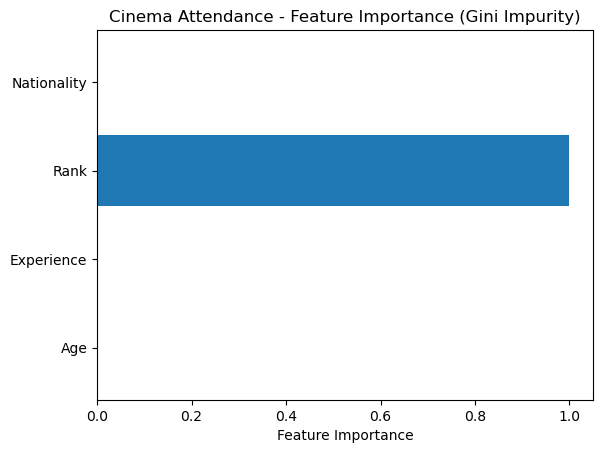

In [22]:
importance_gini = gini_tree.feature_importances_

plt.barh(X.columns, importance_gini)
plt.xlabel('Feature Importance')
plt.title('Cinema Attendance - Feature Importance (Gini Impurity)')
plt.show()

# The following bar plot illustrates the feature that is most important in reducing the impurity of the data at the root node.
# Using the Gini Impurity criterion, the Decision Tree Classifier has deemed Rank to be the most important feature within the data set.

In [24]:
from sklearn.tree import DecisionTreeClassifier

entropy_tree = DecisionTreeClassifier(criterion='entropy', random_state=42)
entropy_tree.fit(X_train, y_train)

# We will also use Information Gain (also referred to as Entropy) as a secondary criterion for ranking the features within the data set.
# Using the Decision Tree Classifier, we set the criterion parameter to 'entropy'.
# The Decision Tree Classifier is then trained on (or fitted to) the training subset.
# Information Gain (Entropy) will measure the disorder at the root node and perform a split on the feature that most diminishes the disorder. 

DecisionTreeClassifier(criterion='entropy', random_state=42)

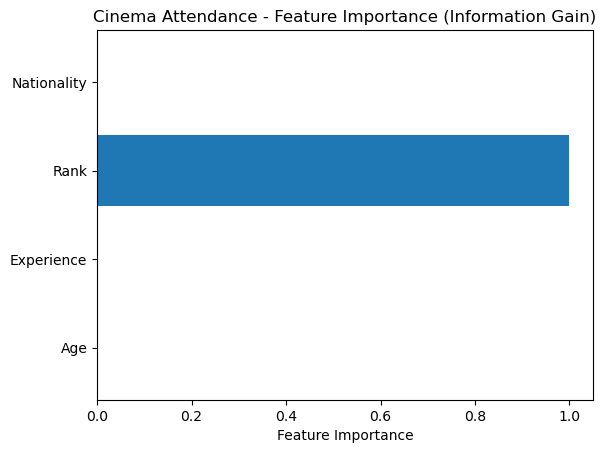

In [25]:
importance_entropy = entropy_tree.feature_importances_

plt.barh(X.columns, importance_entropy)
plt.xlabel('Feature Importance')
plt.title('Cinema Attendance - Feature Importance (Information Gain)')
plt.show()

# The following bar plot illustrates the feature that is most important in reducing the disorder of the data at the root node.
# Using the Information Gain (or Entropy) criterion, the Decision Tree Classifier has deemed Rank to be the most important feature within the data set.

In [26]:
df_featureimportances = pd.DataFrame({'Feature': X.columns,'Gini Impurity': importance_gini,'Information Gain': importance_entropy})

# We can also generate a separate data frame for feature importances based on both criteria.
# Using 'X.column', we compile all of the feature labels from the original data frame.
# We then add the feature importance values determined by the Gini Impurity criterion and the Information Gain (Entropy) criterion using 'importance_gini' and 'importance_entropy', respectively.

In [29]:
df_featureimportances.head()

# The feature importance data frame enables us to compare the feature importance values determined by each criterion.
# Both criteria have given the Rank feature a feature importance value of 1. Therefore, the Rank feature is the most important feature for reducing disorder and impurity when splitting data at the root node.

,Feature,Gini Impurity,Information Gain
0,Age,0.0,0.0
1,Experience,0.0,0.0
2,Rank,1.0,1.0
3,Nationality,0.0,0.0


In [30]:
# TASK 2 -- ROC AUC CURVE

In [100]:
df2_train = pd.read_csv("C:/Users/rotim/Downloads/occupancy+detection/datatraining.txt")

df2_test = pd.read_csv("C:/Users/rotim/Downloads/occupancy+detection/datatest.txt")

# We begin by loading the training and test data sets into separate data frames.
# Because the training and test data have already been divided, we will not need to perform a train_test split before training and testing the model.  

In [102]:
df2_train.head(20)

# We examine the first 20 rows of the training data set in order to understand the features, data types and the structure of the data set.

,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
1,2015-02-04 17:51:00,23.180,27.272000,426.0,721.250000,0.004793,1
2,2015-02-04 17:51:59,23.150,27.267500,429.5,714.000000,0.004783,1
3,2015-02-04 17:53:00,23.150,27.245000,426.0,713.500000,0.004779,1
4,2015-02-04 17:54:00,23.150,27.200000,426.0,708.250000,0.004772,1
5,2015-02-04 17:55:00,23.100,27.200000,426.0,704.500000,0.004757,1
6,2015-02-04 17:55:59,23.100,27.200000,419.0,701.000000,0.004757,1
7,2015-02-04 17:57:00,23.100,27.200000,419.0,701.666667,0.004757,1
8,2015-02-04 17:57:59,23.100,27.200000,419.0,699.000000,0.004757,1
9,2015-02-04 17:58:59,23.100,27.200000,419.0,689.333333,0.004757,1
10,2015-02-04 18:00:00,23.075,27.175000,419.0,688.000000,0.004745,1


In [104]:
df2_test.head(20)

# We also examine the first 20 entries of the test data set.
# Both the training and test data sets have 6 features, which are date, Temperature, Humidity, Light, CO2, and Humidity Ratio. The target variable is Occupancy.
# The data sets are records of room conditions and characteristics measured over time. 
# We will utilize the Random Forest Classifier in order to classify rooms as occupied or unoccupied based on the feature values.

,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
140,2015-02-02 14:19:00,23.7000,26.2720,585.200000,749.200000,0.004764,1
141,2015-02-02 14:19:59,23.7180,26.2900,578.400000,760.400000,0.004773,1
142,2015-02-02 14:21:00,23.7300,26.2300,572.666667,769.666667,0.004765,1
143,2015-02-02 14:22:00,23.7225,26.1250,493.750000,774.750000,0.004744,1
144,2015-02-02 14:23:00,23.7540,26.2000,488.600000,779.000000,0.004767,1
145,2015-02-02 14:23:59,23.7600,26.2600,568.666667,790.000000,0.004779,1
146,2015-02-02 14:25:00,23.7300,26.2900,536.333333,798.000000,0.004776,1
147,2015-02-02 14:25:59,23.7540,26.2900,509.000000,797.000000,0.004783,1
148,2015-02-02 14:26:59,23.7540,26.3500,476.000000,803.200000,0.004794,1
149,2015-02-02 14:28:00,23.7360,26.3900,510.000000,809.000000,0.004796,1


In [105]:
df2_train.describe()

# We use '.describe()' to review the summary statistics for both the training and test data frames.
# From the count statistic, we can determine that there are 8,143 entries that comprise the training data frame.
# The data points under the Temperature, Humdity, Light, CO2, and Humidity Ratio columns are numeric values, which will need to be scaled so that no one particular feature has a disproportionate or overweight impact on the model's occupancy predictions.
# The 'date' column has date and time stamps recorded. The data in this column will not be needed as we will not be forecasting or conducting a time series analysis. Therefore, this feature will be dropped as we build our binary classification model.
# The target variable, Occupancy, is comprised of binary data values, with '1' signifying an occupied room and '0' signifying an unoccupied room. Therefore, encoding will not be necessary.

,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
count,8143.000000,8143.000000,8143.000000,8143.000000,8143.000000,8143.000000
mean,20.619084,25.731507,119.519375,606.546243,0.003863,0.212330
std,1.016916,5.531211,194.755805,314.320877,0.000852,0.408982
min,19.000000,16.745000,0.000000,412.750000,0.002674,0.000000
25%,19.700000,20.200000,0.000000,439.000000,0.003078,0.000000
50%,20.390000,26.222500,0.000000,453.500000,0.003801,0.000000
75%,21.390000,30.533333,256.375000,638.833333,0.004352,0.000000
max,23.180000,39.117500,1546.333333,2028.500000,0.006476,1.000000


In [107]:
df2_test.describe()

# From the count statistic, we can determine that there are 2,665 entries that comprise the test data frame.
# As in the case of the training data frame, the data points under the Temperature, Humdity, Light, CO2, and Humidity Ratio columns are numeric values, which will need to be scaled.
# The date and time stamps recorded in the 'date' column will be dropped as we will not be forecasting or conducting a time series analysis. This feature is not essential for building our binary classification model.
# Additionally, the target variable, Occupancy, is comprised of binary data values for occupied and unoccupied rooms. Thus, no encoding will be necessary.

,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy
count,2665.000000,2665.000000,2665.000000,2665.000000,2665.000000,2665.000000
mean,21.433876,25.353937,193.227556,717.906470,0.004027,0.364728
std,1.028024,2.436842,250.210906,292.681718,0.000611,0.481444
min,20.200000,22.100000,0.000000,427.500000,0.003303,0.000000
25%,20.650000,23.260000,0.000000,466.000000,0.003529,0.000000
50%,20.890000,25.000000,0.000000,580.500000,0.003815,0.000000
75%,22.356667,26.856667,442.500000,956.333333,0.004532,1.000000
max,24.408333,31.472500,1697.250000,1402.250000,0.005378,1.000000


In [108]:
df2_train.info()

# We can determine that the training data frame has no null or missing values since there are 8,143 entries and all the columns have 8,143 non-null entries.

<class 'pandas.core.frame.DataFrame'>
Index: 8143 entries, 1 to 8143
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           8143 non-null   object 
 1   Temperature    8143 non-null   float64
 2   Humidity       8143 non-null   float64
 3   Light          8143 non-null   float64
 4   CO2            8143 non-null   float64
 5   HumidityRatio  8143 non-null   float64
 6   Occupancy      8143 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 508.9+ KB


In [109]:
df2_test.info()

# We can also establish that the test data frame has no null or missing values since there are 2,665 entries and all the columns have 2,665 non-null entries.

<class 'pandas.core.frame.DataFrame'>
Index: 2665 entries, 140 to 2804
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           2665 non-null   object 
 1   Temperature    2665 non-null   float64
 2   Humidity       2665 non-null   float64
 3   Light          2665 non-null   float64
 4   CO2            2665 non-null   float64
 5   HumidityRatio  2665 non-null   float64
 6   Occupancy      2665 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 166.6+ KB


In [110]:
df2_train = df2_train.drop('date', axis=1)

df2_test = df2_test.drop('date', axis=1)

# We drop the 'date' column from both the train and test data frames as it is not essential for the classification model we will be building and training.

In [111]:
X_train = df2_train.iloc[:, :-1]
y_train = df2_train['Occupancy']


X_test = df2_test.iloc[:, :-1]
y_test = df2_test['Occupancy']

# We define the input (X) variable and the target (y) variable for our binary classification model.
# The input 'X' will comprise of all features. We use the 'iloc' function in Pandas to select all columns within the data frame excluding the last column on the right.
# The target 'y' will comprise solely of the Occupancy column, which is the last column on the right side of the data frame. 
# Because the training and test data exist in separate data frames, 'X' and 'y' are defined for each data frame.

In [112]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# We scale the features in the training and test data frames using StandardScaler so that none of the feature has an overweight impact on the classification outcomes.

In [113]:
from sklearn.ensemble import RandomForestClassifier

ranforest = RandomForestClassifier(n_estimators=100, random_state=42)
ranforest.fit(X_train_scaled, y_train)

# We can now build a Random Forest Classifier model and evaluate its predictive performance after fitting it to our training data frame.
# The n_estimators parameter has been set to 100, meaning that the Random Forest model will be comprised of 100 individual trees.

RandomForestClassifier(random_state=42)

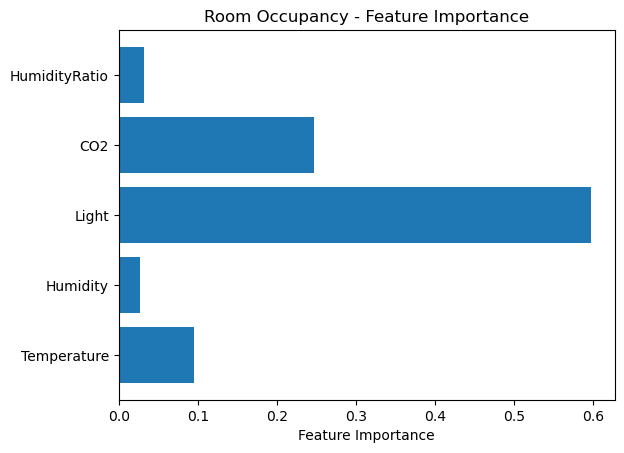

In [122]:
importances = ranforest.feature_importances_

plt.barh(X_train.columns, importances)
plt.xlabel('Feature Importance')
plt.title('Room Occupancy - Feature Importance')
plt.show()

# The following bar plot illustrates the ranking of the features that are most important in reducing the impurity of the training data.
# Using the default Gini Impurity criterion, the Random Forest Classifier has ranked Light as the most important feature for deterining predictions within the training data frame, followed by CO2 and Temperature.

In [115]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

y_pred = ranforest.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f'Random Forest Classifier Accuracy: {accuracy:.2%}')

# The test data frame is used to evaluate the performance of the binary classification model.
# The occupancy predictions for the test data frame are assigned to 'y_pred'.
# At 95.35%, the Random Forest Classifier displays a high level of predictive accuracy.

Random Forest Classifier Accuracy: 95.35%


In [117]:
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred))

# The classification report indicates the Random Forest Classifier displays high predictive performance for both unoccupied rooms, which are rooms with a '0' class label, and occupied rooms, which are rooms with a '1' class label.
# The precision values indicate that 96% of the predicted class 0 (unoccupied room) labels and 94% of the predicted class 1 (occupied room) labels were correct.
# The recall value indicate that the binary classification model was able to correctly identify 97% of actual class 0 instances and 93% of actual class 1 instances.
# As indicated by the support values, the 2,665 entries within the test data frame are comprised of 1,693 class 0 instances and 972 class 1 instances.

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.97      0.96      1693
           1       0.94      0.93      0.94       972

    accuracy                           0.95      2665
   macro avg       0.95      0.95      0.95      2665
weighted avg       0.95      0.95      0.95      2665



In [120]:
from sklearn.metrics import roc_auc_score

y_prob = ranforest.predict_proba(X_test_scaled)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.2f}")


# We calculate the probability of an occupied room (class 1) within the test data frame and assign the predicted probabilities to 'y_prob'.
# We then use the occupancy predictions ('y_pred') and the predicted probabilities of class 1 ('y_prob') to calculate the ROC AUC score.
# The near-perfect ROC-AUC score of 99% suggests the binary classification model exhibits 99% accuracy across all classification thresholds when distinguishing class 0 from class 1. 

ROC-AUC Score: 0.99


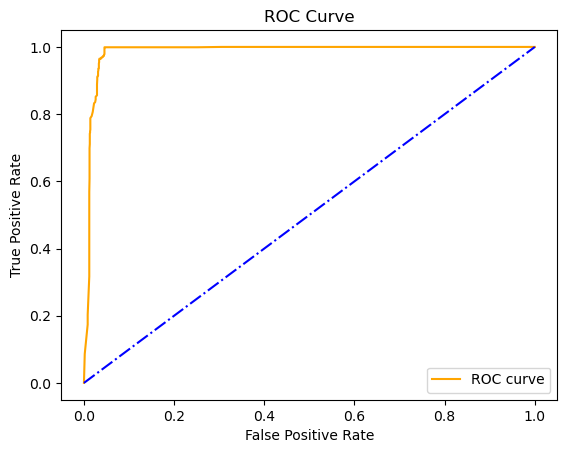

In [121]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='orange', label=f'ROC curve')
plt.plot([0, 1], [0, 1], color='blue', linestyle='-.')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()



# The area under the ROC curve (or AUC) is 0.99, as indicated by the ROC-AUC score.

In [123]:
# TASK 3 -- TIME SERIES REGRESSION

In [124]:
df3 = pd.read_csv("C:/Users/rotim/Downloads/Task3_Data_TimeSeriesRegression.csv")

In [128]:
df3.head(20)

# We examine the first 20 rows of the data set in order to understand the data types, features, and the structure of the data.
# This data set has only 2 variables, 't' (time), which is the input variable, and 'f(t)', which is the output or target variable.
# The data points for 't' are not in sequential order, and there appears to be a non-linear relationship between 't' and 'f(t)'.

,t,f(t)
0,0.479155,0.472010
1,-1.021461,37.567432
2,-4.467154,1507.309054
3,1.130598,5.036163
4,-1.007833,36.566910
5,2.189355,8.786154
6,2.623489,6.818684
7,1.867776,8.895407
8,2.333211,8.346151
9,0.066760,0.543782


In [129]:
df3.describe()

# Upon reviewing the summary statistics, we can ascertain that there are 1,000 entries within the data frame.

,t,f(t)
count,1000.000000,1000.000000
mean,0.029528,276.432619
std,2.912450,490.620460
min,-4.981509,0.000152
25%,-2.571579,3.796317
50%,0.050400,8.999929
75%,2.644340,320.386458
max,4.989894,2092.282079


In [130]:
df3.info()

# We can determine that the data frame has no null or missing values since there are 1,000 entries and all the columns have 1,000 non-null entries.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   t       1000 non-null   float64
 1   f(t)    1000 non-null   float64
dtypes: float64(2)
memory usage: 15.8 KB


In [135]:
X = df3[['t']]
y = df3['f(t)']

# We define the input (X) variable and the target (y) variable for our regression model.
# The input 'X' will consist of the 't' (time) column.
# The target 'y' will consist of the 'f(t)' column.

In [137]:
from sklearn.linear_model import LinearRegression

linear = LinearRegression()
linear.fit(X,y)

# We begin building our regression model by fitting a linear regression model to the data set.

LinearRegression()

In [139]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=3)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly, y)

# Because the data frame suggested a non-linear relationship between the input and target variables, the input variable, 't', is transformed so that it has polynomial features to the 3rd degree.
# This will enable to model to display a 3rd degree or cubic curve when plotted. A 3rd degree (cubic) polynomial regression will exhibit greater flexibility than a 2nd degree (quadratic) polynomial when modeling nonlinear data.
# After the polynomial features for the input variable are created, they are fitted to a linear regression model. This new regression model will then be evaluated on its ability to predict nonlinear patterns within the data set.

LinearRegression()

In [144]:
from sklearn.metrics import r2_score, mean_absolute_error

y_pred = model.predict(X_poly)

r2 = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)

print(f"R2: {r2:.4f}")
print(f"MAE: {mae:.3f}")


# The R2 score implies that the polynomial regression model is able to explain 99.11% of the variance in the 'f(t)' values.
# The Mean Absolute Error measurement of 39.78 indicates that the average difference between predicted and actual values of 'f(t)' is 39.78. This is low considering that values of 'f(t)' range from 0 to 2,092.

R2: 0.9911
MAE: 39.777


C:\Users\rotim\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


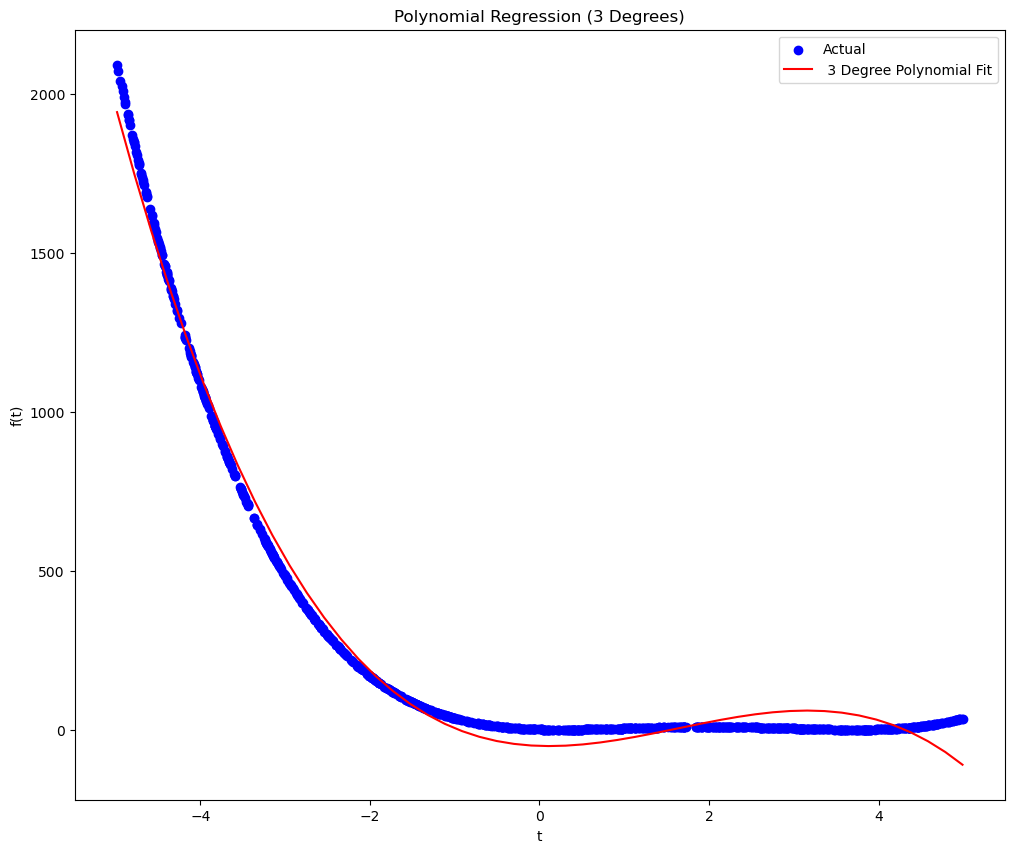

In [158]:
plt.figure(figsize=(12, 10))
plt.scatter(X, y, color='blue', label='Actual')
X_range = np.linspace(X.min(), X.max()).reshape(-1, 1)
X_poly = poly.transform(X_range)
y_pred = model.predict(X_poly)
plt.plot(X_range, y_pred, color='red', label=f' 3 Degree Polynomial Fit')
plt.xlabel('t')
plt.ylabel('f(t)')
plt.title(f'Polynomial Regression (3 Degrees)')
plt.legend()
plt.show()


# The actual data points for the 't' and 'f(t)' coordinate pairs have been plotted with the color blue.
# An array of equidistant input variable values, ranging from the 't' minimum to the 't' maximum value, were created and transformed to have 3rd degree polynomial features.
# Values for 'f(t)' were predicted for each of the transformed input variable values, and the predictions were plotted using the color red to illustrate the polynomial (cubic) curve.
# The red polynomial curve for predictions closely traces the actual plotted data points. This suggests that the polynomial regression model has captured and can effectively predict the non-linear patterns within the data set.

In [160]:
# The data set can be characterized as non-linear since the plotted coordinate pairs form a curve instead of a straight line of fit.
# As 't' increases from its minimum, 'f(t)' displays rapid decay, or an exponential decline, which plateaus as 't' approaches zero.
# As 't' increases beyond zero, 'f(t)' stabilizes at about zero, which could signify its local minimum or lower bound. Thus, 't' would increase toward infinity as 'f(t)' approaches zero.